<h1>Day 3 Of ML</h1>

In [15]:
import pandas as pd
df=pd.read_csv("/home/kanhaiya-bhatt/Downloads/employee_salary_regression.csv")
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   object 
 1   age                1000 non-null   int64  
 2   years_experience   1000 non-null   int64  
 3   education_level    1000 non-null   object 
 4   job_role           1000 non-null   object 
 5   city_tier          1000 non-null   int64  
 6   performance_score  1000 non-null   float64
 7   num_skills         1000 non-null   int64  
 8   remote_work        1000 non-null   int64  
 9   annual_salary_usd  1000 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [16]:
df.columns

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [17]:
df.select_dtypes(include="object").columns

Index(['employee_id', 'education_level', 'job_role'], dtype='object')

In [18]:
df.select_dtypes(include="number").columns

Index(['age', 'years_experience', 'city_tier', 'performance_score',
       'num_skills', 'remote_work', 'annual_salary_usd'],
      dtype='object')

In [19]:
df.isnull().sum()

employee_id          0
age                  0
years_experience     0
education_level      0
job_role             0
city_tier            0
performance_score    0
num_skills           0
remote_work          0
annual_salary_usd    0
dtype: int64

In [20]:
df.duplicated().sum()

0

In [21]:
for col in["education_level","job_role","city_tier"]:
    print(df[col].value_counts())
print()

education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64
job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64
city_tier
3    365
1    319
2    316
Name: count, dtype: int64



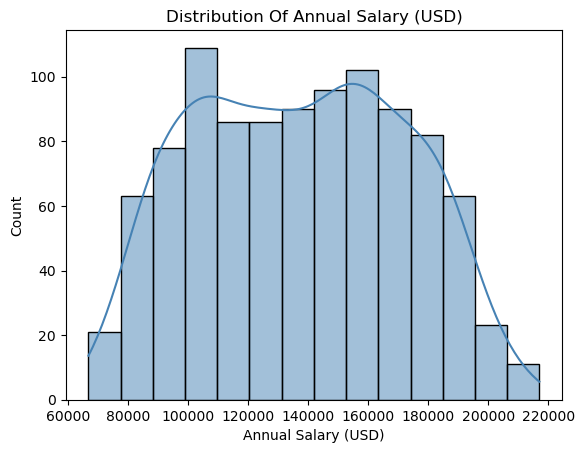

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["annual_salary_usd"],kde=True,color="steelblue")
plt.title("Distribution Of Annual Salary (USD)")
plt.xlabel("Annual Salary (USD)")
plt.show()

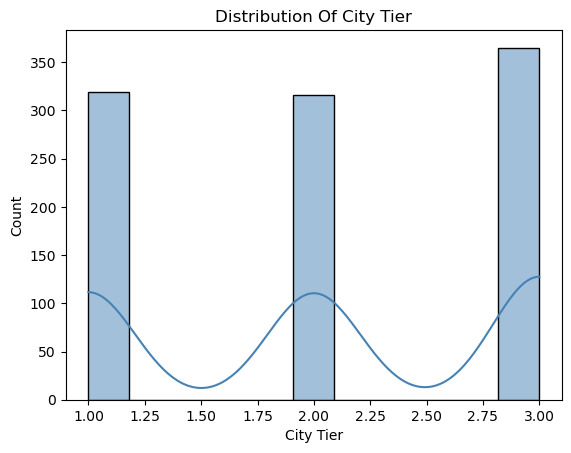

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["city_tier"],kde=True,color="steelblue")
plt.title("Distribution Of City Tier")
plt.xlabel("City Tier")
plt.show()

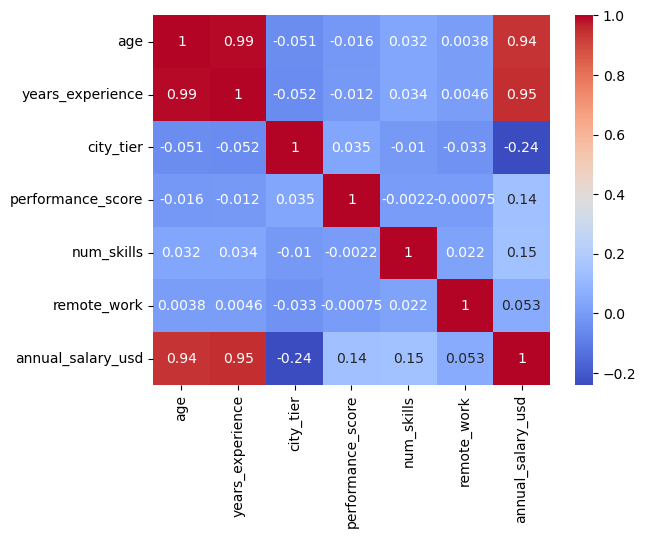

In [24]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [25]:
df_encoded=pd.get_dummies(
    df.drop(columns="employee_id"),
    columns=["education_level","job_role"],
    drop_first=True
)
df_encoded.head()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,education_level_High School,education_level_Master,education_level_PhD,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
0,29,9,1,2.4,3,0,106343.31,False,True,False,False,False,False,False,True
1,27,6,3,2.1,5,1,82852.60,False,False,False,False,True,False,False,False
2,36,13,1,4.1,7,1,142019.59,False,True,False,False,False,False,False,False
3,43,23,1,3.1,7,1,159972.80,True,False,False,True,False,False,False,False
4,24,1,1,3.7,12,1,94126.86,True,False,False,True,False,False,False,False


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
X =df_encoded.drop(columns=["annual_salary_usd"])
y =df_encoded["annual_salary_usd"]

X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training set size:",X_train.shape)
print("Testing set size",X_test.shape)

Training set size: (800, 14)
Testing set size (200, 14)


In [43]:

model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Prediction
y_test_pred = model.predict(X_test)


In [45]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

y_test_pred = model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Testing R²:", round(test_r2, 4))
print("Testing MAE:", round(test_mae, 2))
print("Testing RMSE:", round(test_rmse, 2))

Testing R²: 0.9854
Testing MAE: 3524.83
Testing RMSE: 4381.87


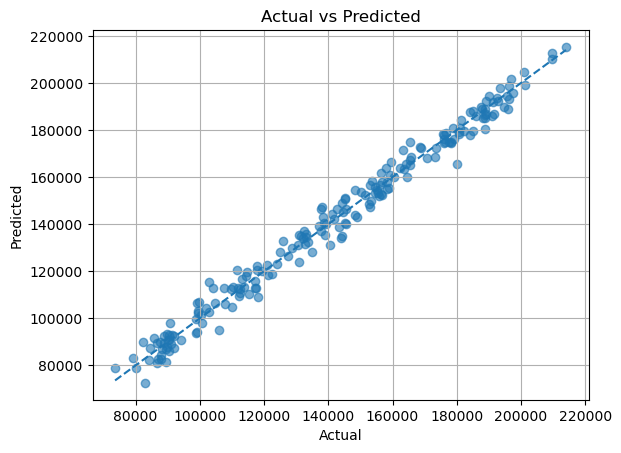

In [47]:
plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()